In [48]:
#import sys, os
#sys.path.append(os.path.abspath(".."))
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

from proxtoolbox.algorithms.metric import Prox
from proxtoolbox.spaces.spd import SymmetricPositiveDefinite

space = SymmetricPositiveDefinite(dimension=5, metric= "AIRM")
S = space.sample(n_samples=20, seed=0, diam=10, dtype=np.float64)
prox = Prox(space=space)
taus = [0.9, 0.7, 0.5, 0.3, 0.1, 0.05, 0.01, 0.005]
means = []
sequences = []
for t in taus:
    fm, x_seq = prox.Frechet_mean(S[0], S, method = "relaxed", 
                            tau= t, 
                            tol=1e-13, max_iter=500,
                            show_progress = True)
    means.append(fm)
    sequences.append(x_seq)                        

100%|██████████| 500/500 [00:15<00:00, 31.44it/s]


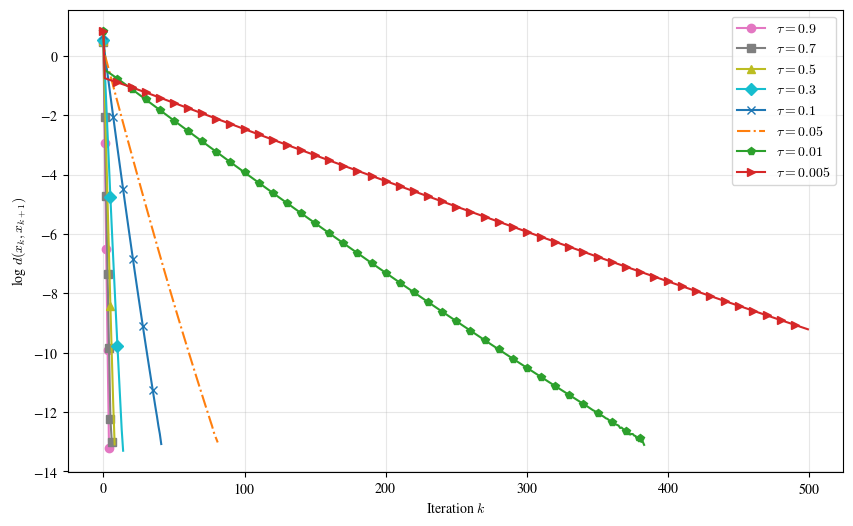

In [51]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['no-latex'])  # no-latex avoids LaTeX dependency



styles = ["-o", "-s", "-^", "-D", "-x", "-.", "-p", "->"]        
colors = [f"C{i+6}" for i in range(len(taus)+10)] 
#colors = plt.cm.Blues(np.linspace(0.9, 0.2, len(taus)))  # avoid too-white and too-dark 
freq = [1, 1, 5, 5, 7, 10, 10,10]
plt.figure(figsize=(10,6))       
for i in range(len(sequences)):
    outer_seq = [x[-1] for x in sequences[i]]
    distances = [np.log10(space.dist(outer_seq[j], outer_seq[j+1])) for j in range(len(outer_seq)-1)]
    plt.plot(distances, styles[i], color=colors[i], markevery=freq[i], label=rf'$\tau={taus[i]}$')


plt.xlabel(r'Iteration $k$')
plt.ylabel(r'log $d(x_{k} , x_{k+1})$')
#plt.title('Convergence of SPD iterates')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
#plt.savefig("/Users/mahshid/Documents/treespace/Mahshid/Latex/images/SPD_iterates.png", 
#bbox_inches="tight",
#dpi=1000
#)

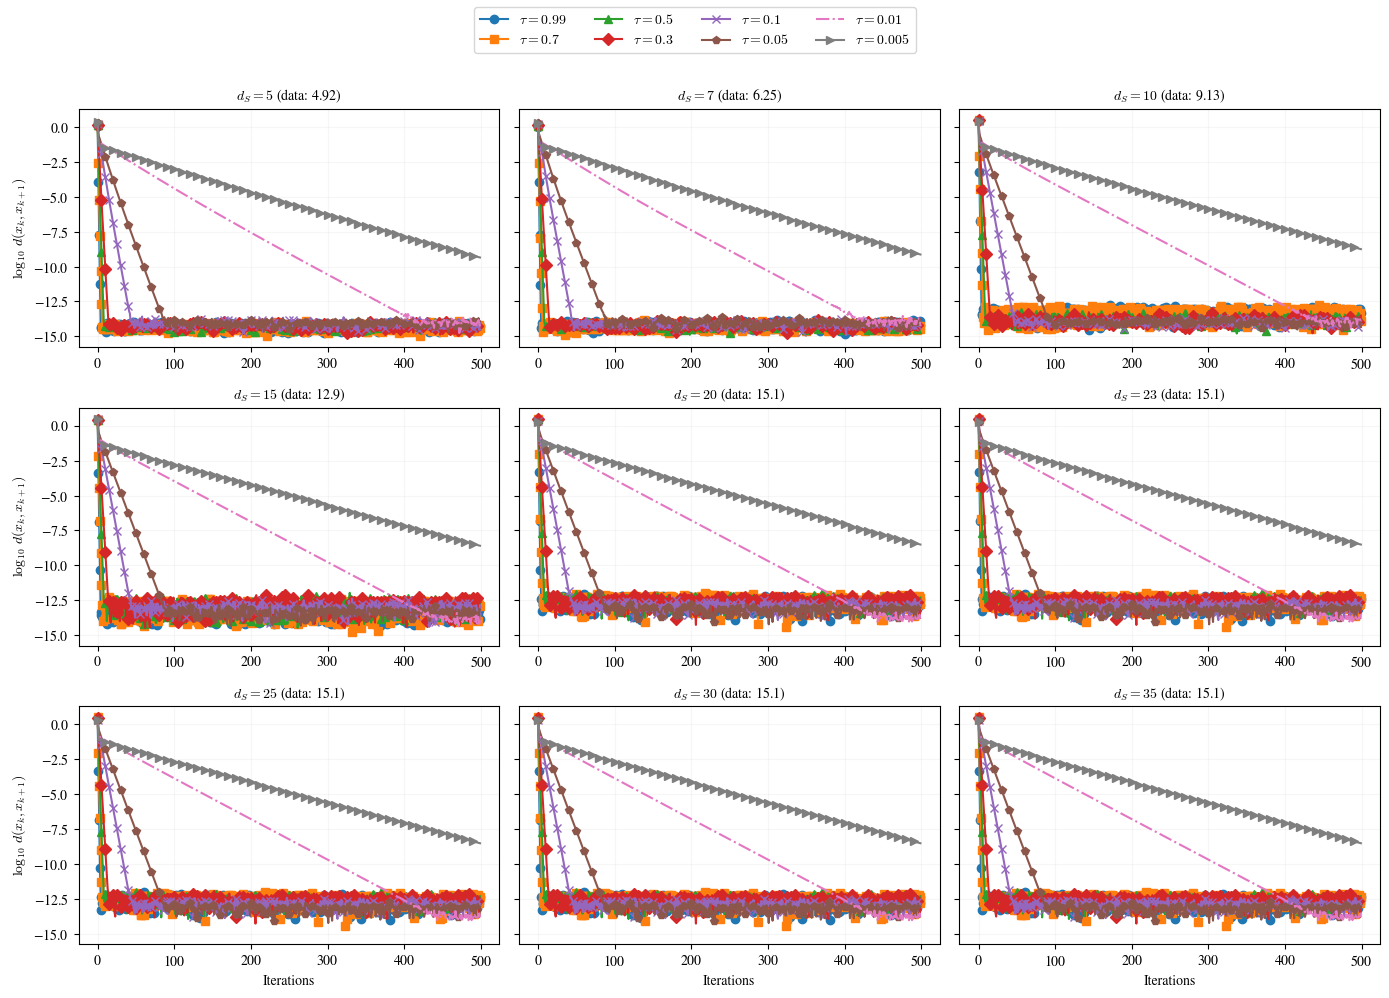

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['no-latex'])

# 9 diameters
data_diam = [5, 7, 10, 15, 20, 23, 25, 30, 35]
taus = [0.99, 0.7, 0.5, 0.3, 0.1, 0.05, 0.01, 0.005]

styles = ["-o", "-s", "-^", "-D", "-x", "-p", "-.", "->"]
colors = [f"C{i}" for i in range(len(taus))]
freq = [1, 1, 5, 5, 5, 10, 10, 10]

fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharey=True)
axes = axes.ravel()

for idx, d in enumerate(data_diam):
    ax = axes[idx]

    space = SymmetricPositiveDefinite(dimension=3, metric= "AIRM")
    S = space.sample(n_samples=20, seed=0, diam=d, dtype=np.float64)

    sample_d, _ = space.diameter(S)

    sequences = []  # one x_seq per tau
    for t in taus:
        fm, x_seq = prox.Frechet_mean(
            S[0], S, method="relaxed",
            tau=t,
            tol=1e-16,
            max_iter=500
        )
        sequences.append(x_seq)

    # plots
    for i in range(len(sequences)):
        last_seq = [x[-1] for x in sequences[i]]
        distances = [np.log10(space.dist(last_seq[j], last_seq[j+1]))
                     for j in range(len(last_seq)-1)]
        ax.plot(distances, styles[i], color=colors[i],
                markevery=freq[i], label=rf'$\tau={taus[i]}$')

    ax.grid(True, alpha=0.1)
    ax.set_title(rf"$d_S={d}$ (data: {sample_d:.3g})", fontsize=10)

# axis labels only on the outside
for ax in axes[6:]:
    ax.set_xlabel("Iterations")
for ax in axes[0::3]:
    ax.set_ylabel(r"$\log_{10}\, d(x_k, x_{k+1})$")

# one legend for the whole figure (instead of 9 legends)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, fontsize=10)

fig.tight_layout(rect=[0, 0, 1, 0.93])
#plt.savefig(
#    "/Users/mahshid/Documents/treespace/Mahshid/Latex/images/sphere_iterates_3x3.png",
#    bbox_inches="tight",
#    dpi=300
#)                                                                  
plt.show()


In [20]:
# sorted samples without diameter bound to see the lower and upper bound of diameters. 
D = []
for d in range(100):
    space = SymmetricPositiveDefinite(dimension=3, metric= "AIRM")
    S = space.sample(n_samples=20, seed=int(np.random.SeedSequence().entropy)% (2**32), dtype=np.float64)
    prox = Prox(space=space)
    D.append(space.diameter(S)[0])


print(np.sort(D))   

[ 7.74846512  7.82983216  7.90236953  8.11270706  8.20318153  8.25314739
  8.31569615  8.56136818  8.94908967  9.09803785  9.2318209   9.39331928
  9.52647208  9.65617734  9.7125279   9.73398304  9.85388325  9.90544152
  9.99272633 10.18134524 10.19464826 10.20000336 10.30809937 10.38700015
 10.45716597 10.54837625 10.60361274 10.69238125 10.71660492 10.80020127
 11.07407148 11.22921158 11.31371736 11.44303422 11.45432169 11.84213546
 11.87392331 11.89832073 12.18387092 12.28835062 12.35000719 12.35233335
 12.37342588 12.55555144 12.58832658 12.60296928 12.63936802 12.70602362
 12.83258444 12.89161161 12.93180595 13.15966914 13.28512287 13.47543782
 13.49646425 13.54199875 13.60752355 13.64280055 13.76904306 13.855161
 13.94180222 13.97195778 14.00853997 14.13911735 14.16946301 14.32740384
 14.55667467 14.59036441 14.66061012 14.66134721 14.94256123 14.94659228
 15.00987715 15.08132477 15.48635545 15.55333388 15.60607655 15.60914584
 15.88993117 15.9845854  16.14997707 16.25951975 16.3

Sample diameter:  20.471857597548055
  step length    diameter    {step length/diameter}
-------------  ----------  ------------------------
        0.9     2.65341                    0.339186
        0.7     2.1586                     0.324284
        0.5     1.65544                    0.302035
        0.3     1.08874                    0.275548
        0.1     0.379936                   0.263203
        0.05    0.190142                   0.262962
        0.01    0.0379384                  0.263585
        0.005   0.0189601                  0.263712


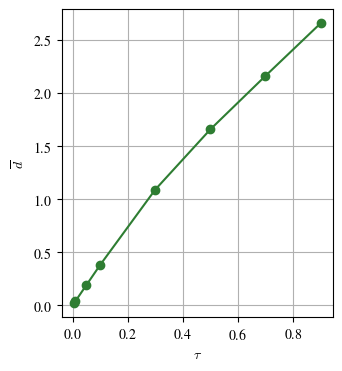

In [52]:
#example of comparing final diameter and step length for one sample
import matplotlib.pyplot as plt
from tabulate import tabulate
S = space.sample(n_samples=20, seed=0, dtype=np.float64)
sample_d, _ = space.diameter(S)
print("Sample diameter: ", sample_d)
diams = [space.diameter(s[-1])[0] for s in sequences]
ratios = [taus[i]/diams[i] for i in range(len(taus))]
plt.figure(figsize=(3.5,4))
plt.plot(taus, diams, marker='o',color='#2e7d32' )
#plt.plot(taus, ratios, marker='o', color='#7b1fa2')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$\overline{d}$')
#plt.title('Comparing final diameter and step length')
plt.grid(True)
#plt.show()
plt.savefig(
    "/Users/mahshid/Documents/git/treespace/Mahshid/Latex/images/spd_ratio.png",
    bbox_inches="tight",
    dpi=1000
)   

rows = list(zip(taus, diams, ratios))
print(tabulate(rows, headers=["step length", "diameter", "{step length/diameter}"]))

In [14]:
# produce the whole data first and then compute subsets in each diameter, centered at the first random data
import matplotlib.pyplot as plt
from tabulate import tabulate
import tqdm
space = SymmetricPositiveDefinite(dimension=4, metric= "AIRM")
data_diam = [5, 7, 10, 15, 20, 23, 25, 30, 35]
taus = [0.99, 0.7, 0.5, 0.3, 0.1, 0.05, 0.01, 0.005]
results = []  # store everything: {"d":..., "sample_d":..., "diams":..., "ratios":...}

# --------- compute once ----------
for d in tqdm.tqdm(data_diam):

    S = space.sample(n_samples=50, seed=0, diam=d, dtype=np.float64)
    sample_d, _ = space.diameter(S)
    sequences = []
    for t in taus:
        fm, x_seq = prox.Frechet_mean(
            S[0], S, method="relaxed",
            tau=t, tol=1e-16, max_iter=500
        )
        sequences.append(x_seq)

    diams  = [space.diameter(s[-1])[0] for s in sequences]
    ratios = [taus[i] / diams[i] for i in range(len(taus))]

    results.append({"d": d, "sample_d": sample_d, "diams": diams, "ratios": ratios})


  0%|          | 0/9 [00:00<?, ?it/s]

100%|██████████| 9/9 [1:01:45<00:00, 411.69s/it]


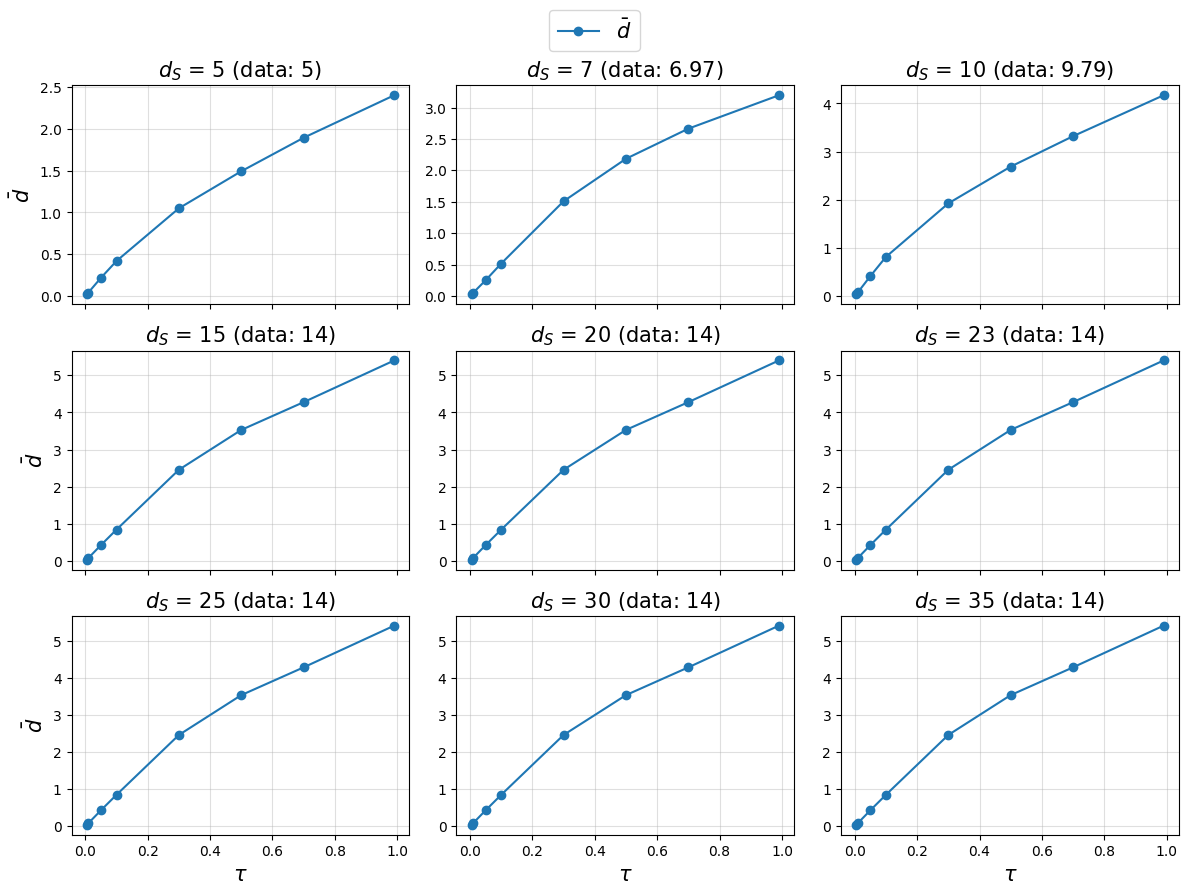

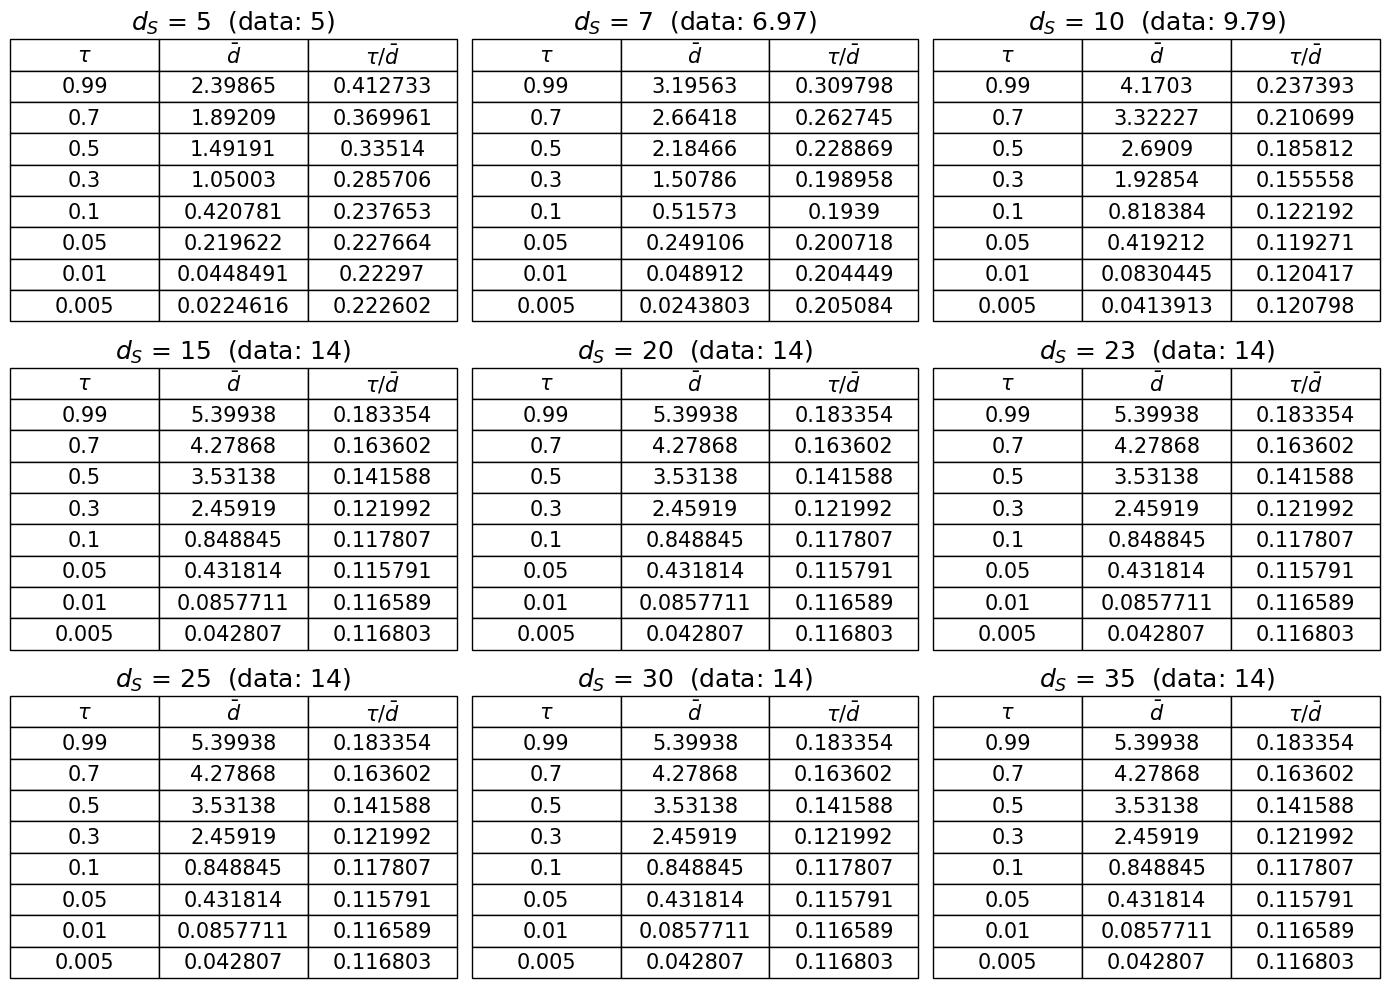

In [15]:

# --------- figure 1: 3x3 plots ----------
fig, axes = plt.subplots(3, 3, figsize=(12, 9), sharex=True)
axes = axes.ravel()


for i, r in enumerate(results):
    ax = axes[i]
    ax.plot(taus, r["diams"], marker="o", label=r"$\bar{d}$")
    #ax.plot(taus, r["ratios"], marker="o", label=r"$\tau/\bar{d}$")
    ax.grid(True, alpha=0.4)
    ax.set_title(fr"$d_S$ = {r['d']} (data: {r['sample_d']:.3g})", fontsize=15)

for ax in axes[6:]:
    ax.set_xlabel(r"$\tau$", fontsize=15)
for ax in axes[0::3]:
    ax.set_ylabel(r"$\bar{d}$", fontsize=15)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("/Users/mahshid/Documents/treespace/Mahshid/Latex/images/sphere_diameters_plot.png", bbox_inches="tight")
#plt.show()

# --------- figure 2: 3x3 tables ----------
figT, axesT = plt.subplots(3, 3, figsize=(14, 10))
axesT = axesT.ravel()

col_labels = [r"$\tau$", r"$\bar{d}$", r"$\tau/\bar{d}$"]


for i, r in enumerate(results):
    ax = axesT[i]
    ax.axis("off")
    ax.set_title(fr"$d_S$ = {r['d']}  (data: {r['sample_d']:.3g})", fontsize=18)

    # format numbers nicely
    cell_text = [
        [f"{taus[j]:.3g}", f"{r['diams'][j]:.6g}", f"{r['ratios'][j]:.6g}"]
        for j in range(len(taus))
    ]

    tbl = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        cellLoc="center",
        loc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(15)
    tbl.scale(1, 1.5)  # (scale on width, scale on height) 

figT.tight_layout()
plt.savefig("/Users/mahshid/Documents/treespace/Mahshid/Latex/images/sphere_diameters_table.png", bbox_inches="tight")

#plt.show()


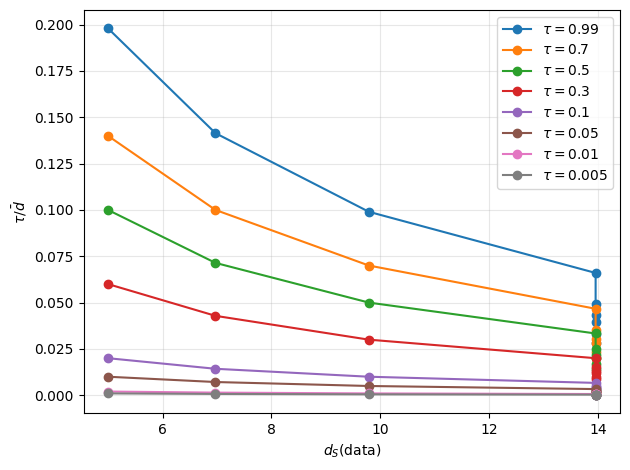

In [16]:
# --- ONE CELL: plot d_S(data) vs ratio = tau / d̄ (where d̄ is data_diam), one curve per tau ---

import numpy as np
import matplotlib.pyplot as plt

taus_list = list(taus)

# map d̄ -> sample_d from your existing `results`
dbar_to_sample_d = {row["d"]: float(row["sample_d"]) for row in results}

# x-axis: d_S(data), sorted by x
dbar_sorted = sorted(data_diam)
xs = np.array([dbar_to_sample_d[d] for d in dbar_sorted], dtype=float)
order = np.argsort(xs)
xs = xs[order]
dbar_sorted = [dbar_sorted[i] for i in order]

plt.figure()
for t in taus_list:
    ys = np.array([t / float(d) for d in dbar_sorted], dtype=float)  # ratio = tau / d̄
    plt.plot(xs, ys, marker="o", label=fr"$\tau={t}$")

plt.xlabel(r"$d_S(\mathrm{data})$")
plt.ylabel(r"$\tau/\bar d$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
